
## Hospital Appointment Data Analysis
This project focuses on cleaning, analyzing, and visualizing hospital appointment data to identify operational insights and appointment trends.

## Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [5]:
df = pd.read_csv("hospital_data.csv")

## Understand Dataset

In [6]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110520 non-null  float64
 6   Neighbourhood   110520 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 11.8+ MB


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (110527, 14)


In [9]:
print(df.columns)


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')


## Review and clean dataset (missing values, duplicates, inconsistencies)

In [10]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               7
Neighbourhood     7
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

0

In [13]:
df.drop_duplicates(inplace=True)

## Perform descriptive analysis (total records, status split, neighbourhood counts)

In [14]:
total_records = len(df)

print("Total Records:", total_records)


Total Records: 110513


In [19]:
appointment_status = df['No-show'].value_counts()

print("Appointment Status Distribution:")
print(appointment_status)

Appointment Status Distribution:
No-show
No     88197
Yes    22316
Name: count, dtype: int64


In [33]:
# Percentage Distribution

status_percentage = df['No-show'].value_counts(normalize=True) * 100

print("Percentage Distribution:")
print(status_percentage)

Percentage Distribution:
No-show
No     79.806901
Yes    20.193099
Name: proportion, dtype: float64


In [20]:
# Rename values for better readability

df['Appointment_Status'] = df['No-show'].replace({
    'No': 'Attended',
    'Yes': 'Missed'
})

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Appointment_Status
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,Attended
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,Attended
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,Attended
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,Attended
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,Attended


In [21]:
# Final Status Counts

final_status = df['Appointment_Status'].value_counts()

print(final_status)

Appointment_Status
Attended    88197
Missed      22316
Name: count, dtype: int64


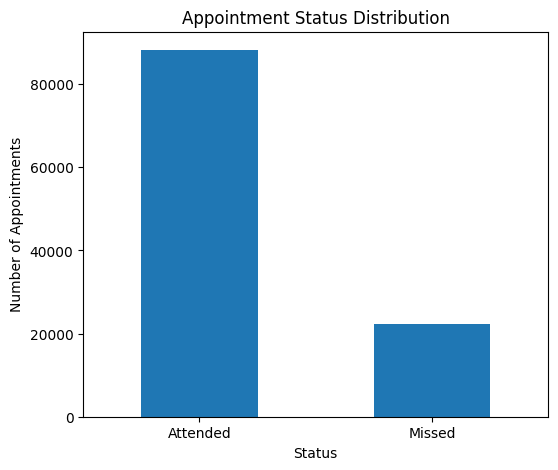

In [22]:
# Appointment Status Bar Chart

plt.figure(figsize=(6,5))

df['Appointment_Status'].value_counts().plot(kind='bar')

plt.title("Appointment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

plt.show()

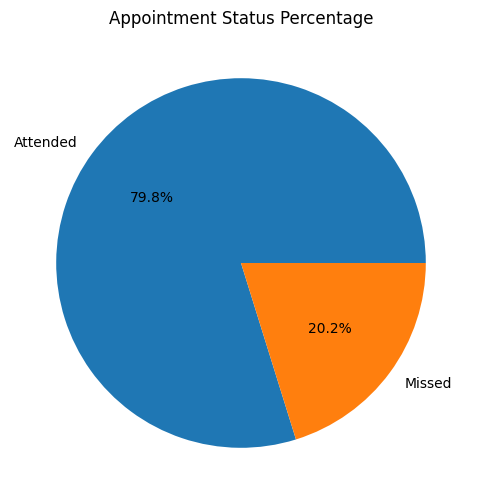

In [23]:
# Appointment Status Pie Chart

plt.figure(figsize=(6,6))

df['Appointment_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Appointment Status Percentage")
plt.ylabel("")

plt.show()

In [24]:
# Top 10 Neighbourhoods

top_neighbourhoods = df['Neighbourhood'].value_counts().head(10)

print(top_neighbourhoods)

Neighbourhood
JARDIM CAMBURI       7716
MARIA ORTIZ          5805
RESISTÊNCIA          4429
JARDIM DA PENHA      3876
ITARARÉ              3514
CENTRO               3333
TABUAZEIRO           3130
SANTA MARTHA         3130
JESUS DE NAZARETH    2853
BONFIM               2772
Name: count, dtype: int64


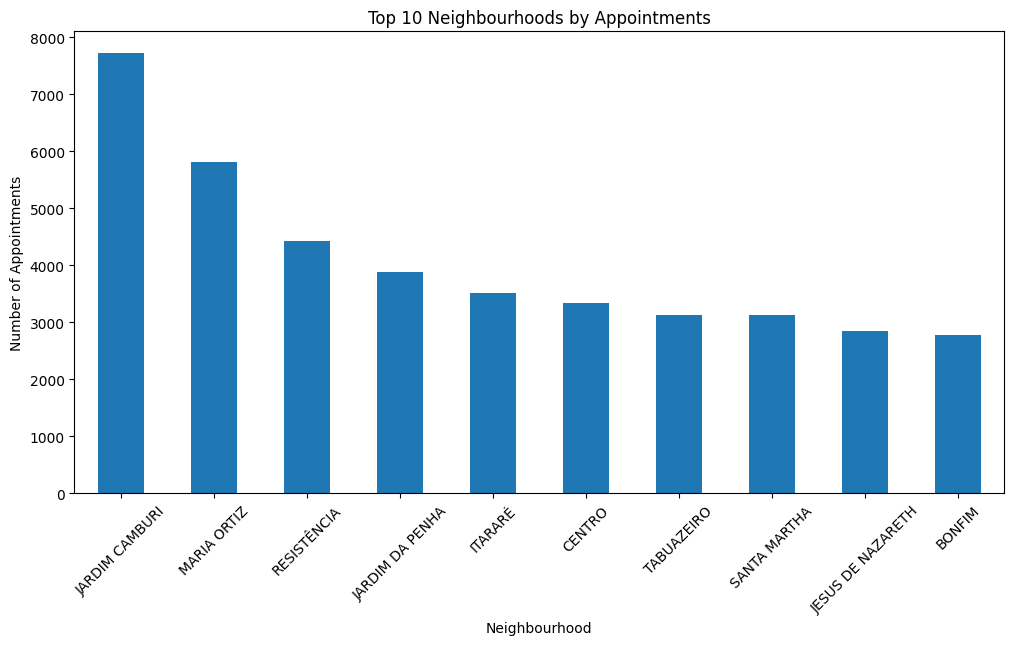

In [25]:
# Top 10 Neighbourhoods Chart

plt.figure(figsize=(12,6))

df['Neighbourhood'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Neighbourhoods by Appointments")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.show()

## Identify one trend/pattern

In [26]:
# Missed Appointments Analysis

missed = df[df['Appointment_Status'] == 'Missed']

missed_neighbourhoods = missed['Neighbourhood'].value_counts().head(10)

print(missed_neighbourhoods)

Neighbourhood
JARDIM CAMBURI       1464
MARIA ORTIZ          1219
ITARARÉ               923
RESISTÊNCIA           905
CENTRO                703
JESUS DE NAZARETH     696
JARDIM DA PENHA       631
CARATOÍRA             591
TABUAZEIRO            573
BONFIM                550
Name: count, dtype: int64


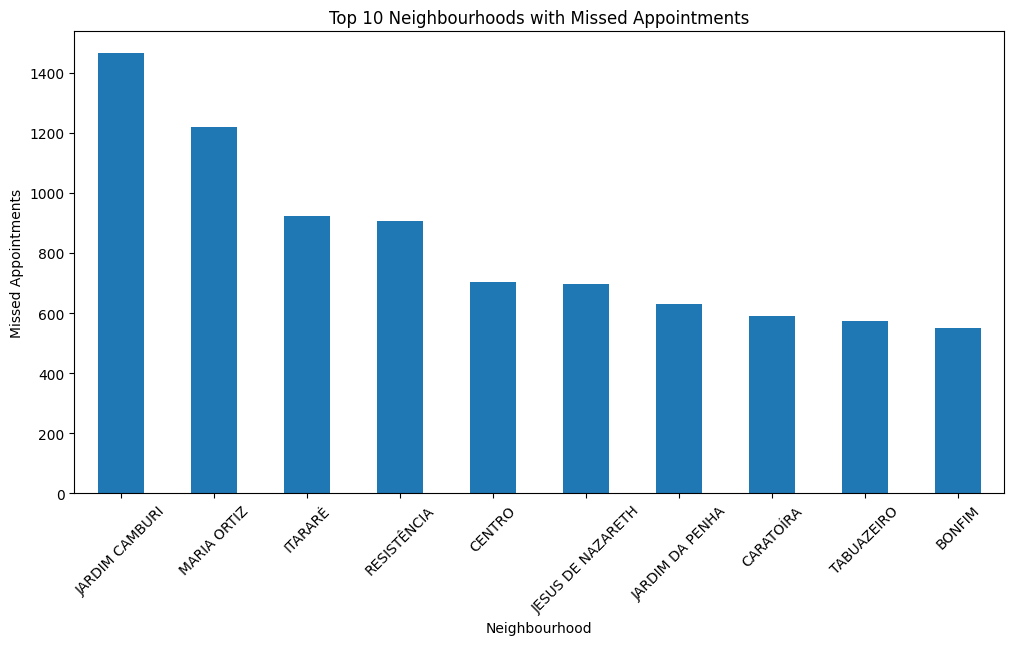

In [27]:
# Missed Appointment by Neighbourhood

plt.figure(figsize=(12,6))

missed['Neighbourhood'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Neighbourhoods with Missed Appointments")
plt.xlabel("Neighbourhood")
plt.ylabel("Missed Appointments")

plt.xticks(rotation=45)

plt.show()


In [28]:
# SMS Reminder Analysis

sms_analysis = pd.crosstab(
    df['SMS_received'],
    df['Appointment_Status']
)

print(sms_analysis)

Appointment_Status  Attended  Missed
SMS_received                        
0                      62501   12534
1                      25696    9782


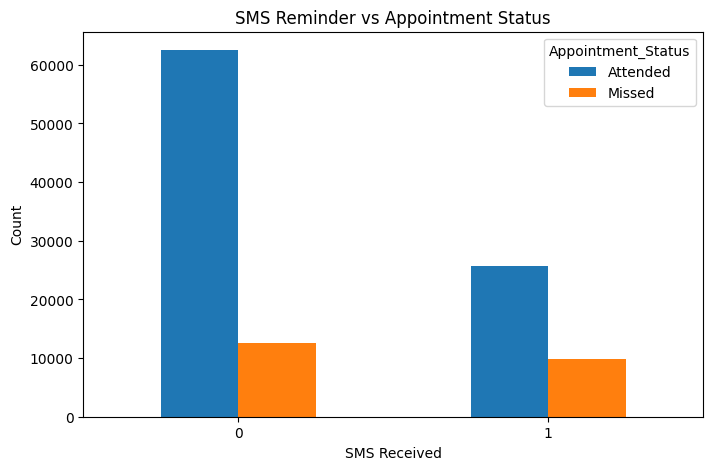

In [29]:
# SMS Reminder Chart

sms_analysis.plot(kind='bar', figsize=(8,5))

plt.title("SMS Reminder vs Appointment Status")
plt.xlabel("SMS Received")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [30]:
# Average Age by Appointment Status

average_age = df.groupby('Appointment_Status')['Age'].mean()

print(average_age)

Appointment_Status
Attended    37.790968
Missed      34.316186
Name: Age, dtype: float64


## Key Findings

1. The dataset was successfully cleaned by handling missing values and duplicate records.

2. Most patients attended their appointments, while a smaller percentage missed scheduled appointments.

3. Certain neighbourhoods showed significantly higher appointment volumes compared to others.

4. Some neighbourhoods had higher missed appointment counts, indicating possible accessibility or communication challenges.

5. SMS reminders appeared to influence appointment attendance patterns and could help reduce missed appointments.

## Recommendation

The hospital should focus on reducing missed appointments by improving reminder systems, increasing patient communication, and monitoring neighbourhoods with high no-show rates more closely.